In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("sales_dataset.csv")

In [3]:
df.head()

,order_id,customer_name,order_date,category,sub_category,product_name,quantity,unit_price,total_price,region
0,1000,Caleb Davis,2025-01-31,Clothing,Jeans,Jeans Try,2,1197,2394,West
1,1001,Misty Herrera,2025-05-05,Clothing,Jeans,Jeans New,9,1509,13581,South
2,1002,Rick Soto,2025-06-09,Clothing,Shoes,Shoes Us,5,1046,5230,East
3,1003,Sean Haas,2025-02-27,Furniture,Desk,Desk Section,10,292,2920,South
4,1004,Ann Hall,2025-06-01,Furniture,Cabinet,Cabinet Center,2,548,1096,North


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   order_id       200 non-null    int64 
 1   customer_name  200 non-null    object
 2   order_date     200 non-null    object
 3   category       200 non-null    object
 4   sub_category   200 non-null    object
 5   product_name   200 non-null    object
 6   quantity       200 non-null    int64 
 7   unit_price     200 non-null    int64 
 8   total_price    200 non-null    int64 
 9   region         200 non-null    object
dtypes: int64(4), object(6)
memory usage: 15.8+ KB


In [5]:
df.shape

(200, 10)

In [6]:
df.describe()

,order_id,quantity,unit_price,total_price
count,200.000000,200.000000,200.000000,200.000000
mean,1099.500000,4.910000,2421.495000,12100.535000
std,57.879185,3.017853,1464.016187,10915.548067
min,1000.000000,1.000000,79.000000,79.000000
25%,1049.750000,2.000000,1120.000000,3060.000000
50%,1099.500000,5.000000,2373.500000,8912.000000
75%,1149.250000,7.000000,3541.750000,19350.750000
max,1199.000000,10.000000,4997.000000,47940.000000


In [7]:
df.columns

Index(['order_id', 'customer_name', 'order_date', 'category', 'sub_category',
       'product_name', 'quantity', 'unit_price', 'total_price', 'region'],
      dtype='object')

In [8]:
df.isnull().sum()

order_id         0
customer_name    0
order_date       0
category         0
sub_category     0
product_name     0
quantity         0
unit_price       0
total_price      0
region           0
dtype: int64

In [9]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
print(missing_percentage)

order_id         0.0
customer_name    0.0
order_date       0.0
category         0.0
sub_category     0.0
product_name     0.0
quantity         0.0
unit_price       0.0
total_price      0.0
region           0.0
dtype: float64


In [11]:
missing_values = df.isnull().sum()
print("Missing values:")
print(missing_values[missing_values > 0])

Missing values:
Series([], dtype: int64)


In [12]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [13]:
df[df.duplicated()]

,order_id,customer_name,order_date,category,sub_category,product_name,quantity,unit_price,total_price,region


In [14]:
df = df.drop_duplicates()

In [22]:
df['quantity'] = df['quantity'].fillna(df['quantity'].mean())
df['unit_price'] = df['unit_price'].fillna(df['unit_price'].mean())
df['total_price'] = df['total_price'].fillna(df['total_price'].mean())
df['category'] = df['category'].fillna(df['category'].mode()[0])
df['sub_category'] = df['sub_category'].fillna(df['sub_category'].mode()[0])
df['product_name'] = df['product_name'].fillna(df['product_name'].mode()[0])
df['region'] = df['region'].fillna(df['region'].mode()[0])
print("\nMissing values after cleaning:")
print(df.isnull().sum())


Missing values after cleaning:
order_id         0
customer_name    0
order_date       0
category         0
sub_category     0
product_name     0
quantity         0
unit_price       0
total_price      0
region           0
dtype: int64


In [16]:
category_revenue = df.groupby(
    'category',
    as_index=False
)['total_price'].sum()

category_revenue.rename(
    columns={'total_price': 'Total Revenue'},
    inplace=True
)

print("Total Revenue by Category:")
display(category_revenue)

Total Revenue by Category:


,category,Total Revenue
0,Clothing,484259
1,Electronics,549302
2,Furniture,714399
3,Grocery,672147


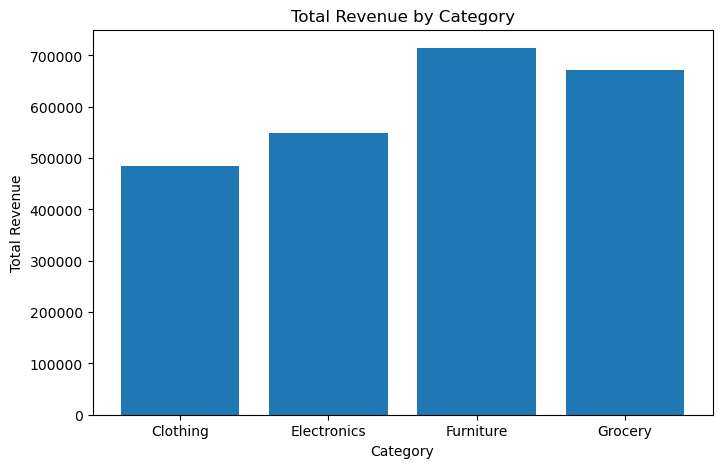

In [24]:
plt.figure(figsize=(8, 5))

plt.bar(
    category_revenue['category'],
    category_revenue['Total Revenue']
)

plt.xlabel("Category")
plt.ylabel("Total Revenue")
plt.title("Total Revenue by Category")

plt.show()

In [20]:
sorted_df = df.sort_values(
    by=['category', 'total_price'],
    ascending=[True, False]
)
print("Data sorted by Category and Total Price:")
display(sorted_df.head(20))

Data sorted by Category and Total Price:


,order_id,customer_name,order_date,category,sub_category,product_name,quantity,unit_price,total_price,region
168,1168,Megan Charles,2025-03-26,Clothing,Jeans,Jeans Card,10,4462,44620,West
59,1059,Miss Rebecca Levine,2025-02-28,Clothing,Shirt,Shirt Look,6,4794,28764,East
157,1157,Patricia Gill,2025-03-23,Clothing,Jacket,Jacket Song,7,3915,27405,East
180,1180,Hailey Cobb,2025-02-19,Clothing,Jacket,Jacket Heart,6,4285,25710,East
82,1082,Kenneth Lee,2025-05-06,Clothing,Jacket,Jacket Realize,7,3486,24402,West
42,1042,David Norris,2025-06-10,Clothing,Shoes,Shoes Far,7,3445,24115,South
171,1171,David Dominguez,2025-03-06,Clothing,Shoes,Shoes Each,8,2902,23216,South
128,1128,Gregory Miller,2025-02-21,Clothing,Jacket,Jacket Image,8,2822,22576,South
62,1062,Jessica Hernandez,2025-05-21,Clothing,Shoes,Shoes Care,7,3208,22456,East
99,1099,Amanda Reeves,2025-04-21,Clothing,Jeans,Jeans Family,5,4419,22095,South


Numerical columns:
['order_id', 'quantity', 'unit_price', 'total_price']

Correlation Matrix:


,order_id,quantity,unit_price,total_price
order_id,1.000000,-0.018182,0.102267,0.099480
quantity,-0.018182,1.000000,0.047996,0.655212
unit_price,0.102267,0.047996,1.000000,0.671318
total_price,0.099480,0.655212,0.671318,1.000000


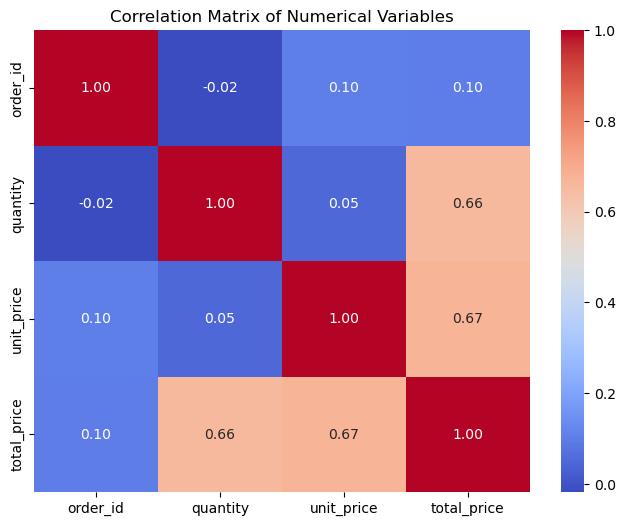

In [23]:
numerical_data = df.select_dtypes(include='number')
print("Numerical columns:")
print(numerical_data.columns.tolist())

correlation_matrix = numerical_data.corr()
print("\nCorrelation Matrix:")
display(correlation_matrix)

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Matrix of Numerical Variables")
plt.show()